# Experiment 2 — Cotton Plant Disease Classification with EfficientNetB0

This notebook trains a six-class cotton leaf disease classifier using the `Cotton leaves/40 Images` dataset. It uses **4,788 images** with **3,840 training**, **480 validation**, and **468 test** images.

The workflow uses an explicit, stratified, file-level split; checking duplicates and near-duplicates; keeping augmentation inside the training pipeline; using ImageNet transfer learning; fine-tuning at a lower learning rate; and reporting macro-F1, per-class metrics, and a confusion matrix.

> Important: do not mix the processed folders such as `5 Black and white`, `HOG brighter`, or `HOG_data` into this experiment. They are alternate representations and may contain transformed copies of the same source images, which can inflate test performance if split independently.


## 1. Install/import dependencies

The notebook is designed for Kaggle. TensorFlow, scikit-learn, NumPy, pandas, Matplotlib, and PIL are normally available there. The optional install line is commented out so that the notebook does not unnecessarily alter the Kaggle environment.


In [1]:
# If running outside Kaggle, uncomment the following line once:
# %pip install -q tensorflow scikit-learn seaborn pillow pandas matplotlib

import os
import json
import hashlib
import random
from pathlib import Path
from collections import Counter, defaultdict

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from PIL import Image, ImageFile

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score, balanced_accuracy_score, classification_report,
    confusion_matrix, f1_score, precision_score, recall_score
)

ImageFile.LOAD_TRUNCATED_IMAGES = True
print("TensorFlow:", tf.__version__)
print("GPUs:", tf.config.list_physical_devices("GPU"))


TensorFlow: 2.20.0
GPUs: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


## 2. Configuration and reproducibility

The constants below deliberately preserve the the experiment's image size, number of classes, batch size, and dataset location. The split is specified in **image counts**, not only percentages, so it remains directly comparable with this experiment.


In [2]:
SEED = 123
random.seed(SEED)
np.random.seed(SEED)
tf.keras.utils.set_random_seed(SEED)
try:
    tf.config.experimental.enable_op_determinism()
except Exception:
    pass

DATA_ROOT = Path("/kaggle/input/datasets/dhamur/cotton-plant-disease/Cotton leaves/40 Images")
OUTPUT_DIR = Path("/kaggle/working/cotton_outputs")
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

IMAGE_SIZE = (256, 256)
IMG_HEIGHT, IMG_WIDTH = IMAGE_SIZE
CHANNELS = 3
BATCH_SIZE = 32
NUM_CLASSES = 6
EXPECTED_TOTAL = 4788
TRAIN_COUNT = 3840
VAL_COUNT = 480
TEST_COUNT = 468

CLASS_NAMES = [
    "Aphids",
    "Army worm",
    "Bacterial blight",
    "Healthy",
    "Powdery mildew",
    "Target spot",
]

print("Dataset root:", DATA_ROOT)
print("Output directory:", OUTPUT_DIR)


Dataset root: /kaggle/input/datasets/dhamur/cotton-plant-disease/Cotton leaves/40 Images
Output directory: /kaggle/working/cotton_outputs


## 3. Discover files, verify labels, and audit image integrity

This step reads only the intended `40 Images` directory. It validates the six expected class folders, checks that the total is 4,788, attempts to open every image, and records exact perceptual hashes. Exact-hash duplicates are reported so they can be inspected before training.


In [3]:
VALID_EXTENSIONS = {".jpg", ".jpeg", ".png", ".bmp", ".gif", ".webp"}

if not DATA_ROOT.exists():
    raise FileNotFoundError(
        f"Dataset directory not found: {DATA_ROOT}. "
        "On Kaggle, add the dhamur/cotton-plant-disease dataset as an input."
    )

missing_classes = [c for c in CLASS_NAMES if not (DATA_ROOT / c).is_dir()]
extra_dirs = sorted(p.name for p in DATA_ROOT.iterdir() if p.is_dir() and p.name not in CLASS_NAMES)
if missing_classes:
    raise ValueError(f"Missing expected class directories: {missing_classes}")
if extra_dirs:
    print("Warning: unexpected directories found and ignored:", extra_dirs)

records = []
for class_index, class_name in enumerate(CLASS_NAMES):
    for path in sorted((DATA_ROOT / class_name).rglob("*")):
        if path.is_file() and path.suffix.lower() in VALID_EXTENSIONS:
            records.append({
                "filepath": str(path),
                "filename": path.name,
                "class_name": class_name,
                "label": class_index,
            })

df = pd.DataFrame(records).sort_values("filepath").reset_index(drop=True)
print("Total images:", len(df))
print(df["class_name"].value_counts().reindex(CLASS_NAMES))

assert len(df) == EXPECTED_TOTAL, (
    f"Expected {EXPECTED_TOTAL} images in the main dataset, found {len(df)}"
)
assert set(df["class_name"]) == set(CLASS_NAMES)

valid_rows, corrupt_files = [], []
for row in df.itertuples(index=False):
    try:
        with Image.open(row.filepath) as image:
            image.verify()
        with Image.open(row.filepath) as image:
            width, height = image.size
        valid_rows.append((row.filepath, width, height))
    except Exception as exc:
        corrupt_files.append({"filepath": row.filepath, "error": repr(exc)})

if corrupt_files:
    print("Corrupt/unreadable files:", len(corrupt_files))
    display(pd.DataFrame(corrupt_files).head())
    raise ValueError("Remove or repair corrupt files before training.")

size_df = pd.DataFrame(valid_rows, columns=["filepath", "width", "height"])
df = df.merge(size_df, on="filepath", how="left")
print("Image dimensions:")
display(df[["width", "height"]].describe())


Total images: 4788
class_name
Aphids              800
Army worm           800
Bacterial blight    800
Healthy             800
Powdery mildew      800
Target spot         788
Name: count, dtype: int64
Image dimensions:


,width,height
count,4788.000000,4788.00000
mean,625.775063,521.73914
std,444.359958,353.45944
min,113.000000,121.00000
25%,400.000000,333.00000
50%,500.000000,400.00000
75%,718.000000,618.00000
max,3264.000000,2831.00000


In [4]:
def sha256_file(path, chunk_size=1024 * 1024):
    digest = hashlib.sha256()
    with open(path, "rb") as handle:
        for chunk in iter(lambda: handle.read(chunk_size), b""):
            digest.update(chunk)
    return digest.hexdigest()

# Exact file hashes are useful for duplicate detection. This is intentionally run once.
df["sha256"] = [sha256_file(path) for path in df["filepath"]]
exact_duplicate_groups = df.groupby("sha256").filter(lambda g: len(g) > 1)
print("Exact duplicate files:", len(exact_duplicate_groups))
if len(exact_duplicate_groups):
    display(exact_duplicate_groups[["filepath", "class_name", "sha256"]].head(20))
else:
    print("No exact duplicate files found inside the main 40 Images directory.")


Exact duplicate files: 907


,filepath,class_name,sha256
5,/kaggle/input/datasets/dhamur/cotton-plant-dis...,Aphids,ff4da59ff8a5fdaa03615a9f5a803eb5cf686469dc7aa1...
19,/kaggle/input/datasets/dhamur/cotton-plant-dis...,Aphids,ff4da59ff8a5fdaa03615a9f5a803eb5cf686469dc7aa1...
40,/kaggle/input/datasets/dhamur/cotton-plant-dis...,Aphids,321120ce43a33e08e7940ea5d5050875a9967bd461d70b...
41,/kaggle/input/datasets/dhamur/cotton-plant-dis...,Aphids,a9c5476855e6d5fa3ff25b95b9003fcd1a5dba2e4ef044...
42,/kaggle/input/datasets/dhamur/cotton-plant-dis...,Aphids,0175133df3a4c02359f38f8e1e1d1a4726e9de702c46d2...
43,/kaggle/input/datasets/dhamur/cotton-plant-dis...,Aphids,4677ba05800525634c765fbb902d2f8f84db9887112b24...
44,/kaggle/input/datasets/dhamur/cotton-plant-dis...,Aphids,6d10162c0412de142645bed7ad654dd208bc8097c78946...
45,/kaggle/input/datasets/dhamur/cotton-plant-dis...,Aphids,efc4a7650b925d7386cbd5988da6ca8693e92caa69857c...
46,/kaggle/input/datasets/dhamur/cotton-plant-dis...,Aphids,bd2ab0c65f68917314d3e373c84a692eb271300a436f61...
47,/kaggle/input/datasets/dhamur/cotton-plant-dis...,Aphids,4f592857074e39a8f729389470d43b3537b030956d6ac5...


## 4. Inspect the class distribution and sample images

The six classes are nearly balanced. The following plots provide a quick visual and statistical sanity check before splitting.


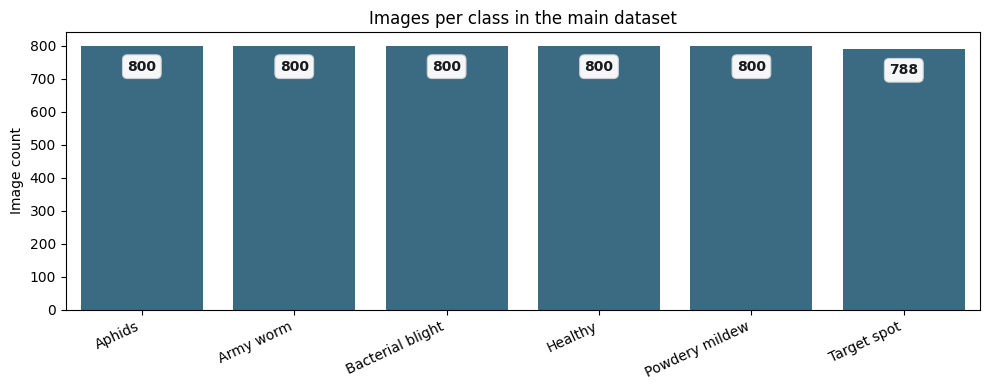

In [5]:
plt.figure(figsize=(10, 4))
ax = sns.countplot(data=df, x="class_name", order=CLASS_NAMES, color="#2f6f8f")

plt.title("Images per class in the main dataset")
plt.xlabel("")
plt.ylabel("Image count")
plt.xticks(rotation=25, ha="right")

# Add count labels inside the top of each bar (rounded white button style)
for p in ax.patches:
    height = p.get_height()
    ax.annotate(
        f"{int(height)}",
        (p.get_x() + p.get_width() / 2., height * 0.92),   # slightly inside the top edge
        ha="center",
        va="center",
        fontsize=10,
        fontweight="bold",
        color="#1a1a1a",
        bbox=dict(
            boxstyle="round,pad=0.35",
            facecolor="white",
            edgecolor="#d0d0d0",
            alpha=0.95,
            linewidth=0.8
        )
    )

plt.tight_layout()
plt.show()

## 5. Create the exact 3,840 / 480 / 468 stratified split

The the experiment split batches after loading. This version splits file paths first, preserving the the specified image counts while guaranteeing that each class is represented in every partition. The test set remains untouched during model selection.


In [6]:
# First hold out exactly 468 test images.
dev_df, test_df = train_test_split(
    df,
    test_size=TEST_COUNT,
    random_state=SEED,
    shuffle=True,
    stratify=df["label"],
)

# Then hold out exactly 480 validation images from the remaining 4,320 development images.
train_df, val_df = train_test_split(
    dev_df,
    test_size=VAL_COUNT,
    random_state=SEED,
    shuffle=True,
    stratify=dev_df["label"],
)

train_df = train_df.sort_values("filepath").reset_index(drop=True)
val_df = val_df.sort_values("filepath").reset_index(drop=True)
test_df = test_df.sort_values("filepath").reset_index(drop=True)

assert len(train_df) == TRAIN_COUNT
assert len(val_df) == VAL_COUNT
assert len(test_df) == TEST_COUNT
assert set(train_df.filepath).isdisjoint(val_df.filepath)
assert set(train_df.filepath).isdisjoint(test_df.filepath)
assert set(val_df.filepath).isdisjoint(test_df.filepath)

print({"train": len(train_df), "validation": len(val_df), "test": len(test_df)})
print()
print("Training distribution:")
display(pd.crosstab(train_df.class_name, columns="count").reindex(CLASS_NAMES))
print("Validation distribution:")
display(pd.crosstab(val_df.class_name, columns="count").reindex(CLASS_NAMES))
print("Test distribution:")
display(pd.crosstab(test_df.class_name, columns="count").reindex(CLASS_NAMES))


{'train': 3840, 'validation': 480, 'test': 468}

Training distribution:


col_0,count
class_name,
Aphids,642
Army worm,642
Bacterial blight,641
Healthy,641
Powdery mildew,642
Target spot,632


Validation distribution:


col_0,count
class_name,
Aphids,80
Army worm,80
Bacterial blight,80
Healthy,81
Powdery mildew,80
Target spot,79


Test distribution:


col_0,count
class_name,
Aphids,78
Army worm,78
Bacterial blight,79
Healthy,78
Powdery mildew,78
Target spot,77


## 6. Build TensorFlow datasets

Images are decoded and resized to 256×256. Training augmentation is applied only to the training dataset. Validation and test images use deterministic preprocessing.


In [7]:
AUTOTUNE = tf.data.AUTOTUNE

def decode_resize(path, label):
    image = tf.io.read_file(path)
    image = tf.image.decode_image(image, channels=CHANNELS, expand_animations=False)
    image.set_shape([None, None, CHANNELS])
    image = tf.image.resize(image, IMAGE_SIZE, antialias=True)
    image = tf.cast(image, tf.float32) / 255.0
    return image, label

def make_dataset(frame, training=False):
    paths = frame["filepath"].to_numpy()
    labels = frame["label"].to_numpy(dtype=np.int32)
    ds = tf.data.Dataset.from_tensor_slices((paths, labels))
    if training:
        ds = ds.shuffle(len(frame), seed=SEED, reshuffle_each_iteration=True)
    ds = ds.map(decode_resize, num_parallel_calls=AUTOTUNE)
    ds = ds.batch(BATCH_SIZE, drop_remainder=False)
    return ds.prefetch(AUTOTUNE)

train_raw = make_dataset(train_df, training=True)
val_ds = make_dataset(val_df, training=False)
test_ds = make_dataset(test_df, training=False)

print("Train batches:", tf.data.experimental.cardinality(train_raw).numpy())
print("Validation batches:", tf.data.experimental.cardinality(val_ds).numpy())
print("Test batches:", tf.data.experimental.cardinality(test_ds).numpy())

for sample_images, _ in train_raw.take(1):
    print("Dataset input range:", float(tf.reduce_min(sample_images)), float(tf.reduce_max(sample_images)))
    assert float(tf.reduce_min(sample_images)) >= 0.0
    assert float(tf.reduce_max(sample_images)) <= 1.0 + 1e-5


I0000 00:00:1787167512.173696      58 gpu_device.cc:2020] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 15511 MB memory:  -> device: 0, name: Tesla P100-PCIE-16GB, pci bus id: 0000:00:04.0, compute capability: 6.0


Train batches: 120
Validation batches: 15
Test batches: 15
Dataset input range: 0.0 1.000000238418579


## 7. Define domain-appropriate augmentation

The augmentation is intentionally moderate. It changes viewpoint and lighting without aggressively obscuring the lesions that distinguish the classes.


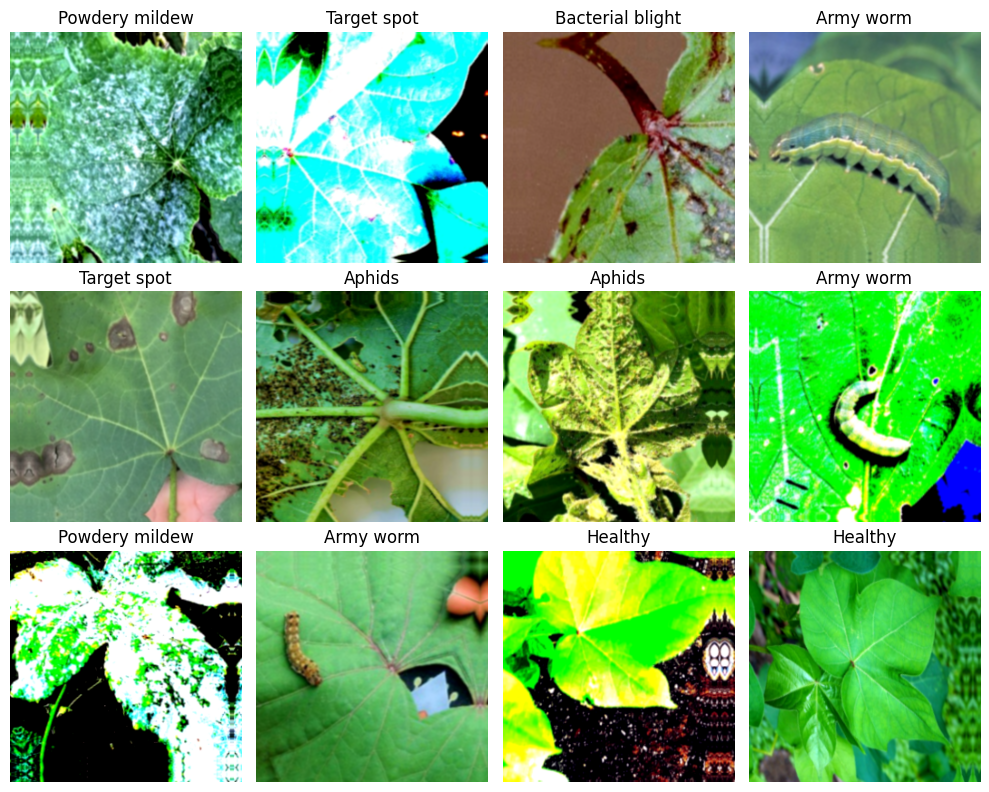

In [8]:
data_augmentation = keras.Sequential(
    [
        layers.RandomFlip("horizontal"),
        layers.RandomRotation(0.08),
        layers.RandomZoom(height_factor=(-0.10, 0.10), width_factor=(-0.10, 0.10)),
        layers.RandomTranslation(height_factor=0.08, width_factor=0.08),
        layers.RandomContrast(0.15),
    ],
    name="data_augmentation",
)

# Preview augmented samples.
for images, labels in train_raw.take(1):
    augmented = data_augmentation(images[:12], training=True)
    fig, axes = plt.subplots(3, 4, figsize=(10, 8))
    for ax, image, label in zip(axes.flat, augmented, labels[:12]):
        ax.imshow(tf.clip_by_value(image, 0, 1))
        ax.set_title(CLASS_NAMES[int(label)])
        ax.axis("off")
    plt.tight_layout()
    plt.show()


## 8. Build the EfficientNetB0 transfer-learning model

EfficientNetB0 is initialized with ImageNet weights. Its backbone is frozen for the first stage so the new classifier head can learn the six-class task without immediately changing the pretrained representation. The input pipeline stores images in `[0, 1]`; the model converts them back to `[0, 255]` immediately before EfficientNet because this Keras EfficientNet implementation includes its own preprocessing. Augmentation is connected without a hard-coded `training=True`, so it is active during training and inactive during validation, testing, and inference.


In [9]:
base_model = keras.applications.EfficientNetB0(
    include_top=False,
    weights="imagenet",
    input_shape=(*IMAGE_SIZE, CHANNELS),
)
base_model.trainable = False

inputs = keras.Input(shape=(*IMAGE_SIZE, CHANNELS), name="image")
x = data_augmentation(inputs)
# The input pipeline stores images in [0, 1]. Keras EfficientNet expects [0, 255].
# Its built-in preprocessing layer performs the normalization internally.
x = layers.Rescaling(255.0, name="to_efficientnet_pixel_range")(x)
x = base_model(x, training=False)
x = layers.GlobalAveragePooling2D(name="global_average_pooling")(x)
x = layers.BatchNormalization(name="classifier_batch_norm")(x)
x = layers.Dropout(0.35, name="classifier_dropout")(x)
outputs = layers.Dense(NUM_CLASSES, activation="softmax", name="predictions")(x)
model = keras.Model(inputs, outputs, name="cotton_efficientnetb0")

model.summary()


16705208/16705208 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


Model: "cotton_efficientnetb0"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ image (InputLayer)              │ (None, 256, 256, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ data_augmentation (Sequential)  │ (None, 256, 256, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ to_efficientnet_pixel_range     │ (None, 256, 256, 3)    │             0 │
│ (Rescaling)                     │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ efficientnetb0 (Functional)     │ (None, 8, 8, 1280)     │     4,049,571 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling          │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ classifier_batch_norm           │ (None, 1280)           │         5,120 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ classifier_dropout (Dropout)    │ (None, 1280)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ predictions (Dense)             │ (None, 6)              │         7,686 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,062,377 (15.50 MB)

 Trainable params: 10,246 (40.02 KB)

 Non-trainable params: 4,052,131 (15.46 MB)

## 9. Compile callbacks and train the frozen-backbone stage

The checkpoint is selected using validation macro-F1, which is more informative than accuracy when assessing all six classes. A separate CSV log is written to the output directory.


In [10]:
class MacroF1Callback(keras.callbacks.Callback):
    def __init__(self, validation_data, validation_frame, batch_size=32):
        super().__init__()
        self.validation_data = validation_data
        self.validation_frame = validation_frame
        self.batch_size = batch_size
        self.values = []

    def on_epoch_end(self, epoch, logs=None):
        y_true = self.validation_frame["label"].to_numpy()
        y_prob = self.model.predict(self.validation_data, verbose=0)
        y_pred = np.argmax(y_prob, axis=1)
        score = f1_score(y_true, y_pred, average="macro")
        self.values.append(float(score))
        logs = logs or {}
        logs["val_macro_f1"] = float(score)
        print(f" - val_macro_f1: {score:.4f}")

macro_f1_callback = MacroF1Callback(val_ds, val_df, BATCH_SIZE)

def make_callbacks(stage_name):
    return [
        macro_f1_callback,
        keras.callbacks.ModelCheckpoint(
            OUTPUT_DIR / f"best_{stage_name}.keras",
            monitor="val_macro_f1",
            mode="max",
            save_best_only=True,
            verbose=1,
        ),
        keras.callbacks.EarlyStopping(
            monitor="val_macro_f1",
            mode="max",
            patience=8,
            restore_best_weights=True,
            verbose=1,
        ),
        keras.callbacks.ReduceLROnPlateau(
            monitor="val_loss",
            factor=0.25,
            patience=3,
            min_lr=1e-7,
            verbose=1,
        ),
        keras.callbacks.CSVLogger(OUTPUT_DIR / f"{stage_name}_training.csv"),
    ]

model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=1e-3),
    loss=keras.losses.SparseCategoricalCrossentropy(),
    metrics=[keras.metrics.SparseCategoricalAccuracy(name="accuracy")],
)

history_head = model.fit(
    train_raw,
    validation_data=val_ds,
    epochs=25,
    callbacks=make_callbacks("head"),
    verbose=1,
)


Epoch 1/25


E0000 00:00:1787167532.771101      58 meta_optimizer.cc:967] layout failed: INVALID_ARGUMENT: Size of values 0 does not match size of permutation 4 @ fanin shape inStatefulPartitionedCall/cotton_efficientnetb0_1/efficientnetb0_1/block2b_drop_1/stateless_dropout/SelectV2-2-TransposeNHWCToNCHW-LayoutOptimizer


120/120 ━━━━━━━━━━━━━━━━━━━━ 0s 124ms/step - accuracy: 0.5451 - loss: 1.3405 - val_macro_f1: 0.8969

Epoch 1: val_macro_f1 improved from None to 0.89686, saving model to /kaggle/working/cotton_outputs/best_head.keras

Epoch 1: finished saving model to /kaggle/working/cotton_outputs/best_head.keras
120/120 ━━━━━━━━━━━━━━━━━━━━ 42s 216ms/step - accuracy: 0.7047 - loss: 0.8727 - val_accuracy: 0.8958 - val_loss: 0.4611 - val_macro_f1: 0.8969 - learning_rate: 0.0010
Epoch 2/25
120/120 ━━━━━━━━━━━━━━━━━━━━ 0s 124ms/step - accuracy: 0.8735 - loss: 0.3787 - val_macro_f1: 0.9280

Epoch 2: val_macro_f1 improved from 0.89686 to 0.92799, saving model to /kaggle/working/cotton_outputs/best_head.keras

Epoch 2: finished saving model to /kaggle/working/cotton_outputs/best_head.keras
120/120 ━━━━━━━━━━━━━━━━━━━━ 20s 166ms/step - accuracy: 0.8836 - loss: 0.3499 - val_accuracy: 0.9271 - val_loss: 0.2414 - val_macro_f1: 0.9280 - learning_rate: 0.0010
Epoch 3/25
120/120 ━━━━━━━━━━━━━━━━━━━━ 0s 125ms/step 

## 10. Fine-tune the upper part of EfficientNet

Only the upper backbone layers are unfrozen, while BatchNormalization layers remain frozen for stable transfer learning on this dataset size. The learning rate is reduced substantially for fine-tuning.


In [11]:
# Start from the best frozen-backbone checkpoint.
head_checkpoint = OUTPUT_DIR / "best_head.keras"
if head_checkpoint.exists():
    model = keras.models.load_model(head_checkpoint)
    # Reattach the callback's model reference automatically during fit.

base_model = model.get_layer("efficientnetb0")
base_model.trainable = True

# Freeze most layers and fine-tune only the final 40 non-BatchNorm layers.
for layer in base_model.layers:
    layer.trainable = False
for layer in base_model.layers[-40:]:
    if not isinstance(layer, layers.BatchNormalization):
        layer.trainable = True

trainable_count = sum(int(layer.trainable) for layer in model.layers)
print("Trainable layers:", trainable_count)

model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=1e-5),
    loss=keras.losses.SparseCategoricalCrossentropy(),
    metrics=[keras.metrics.SparseCategoricalAccuracy(name="accuracy")],
)

history_finetune = model.fit(
    train_raw,
    validation_data=val_ds,
    epochs=35,
    callbacks=make_callbacks("finetune"),
    verbose=1,
)


Trainable layers: 8
Epoch 1/35


E0000 00:00:1787167920.613793      58 meta_optimizer.cc:967] layout failed: INVALID_ARGUMENT: Size of values 0 does not match size of permutation 4 @ fanin shape inStatefulPartitionedCall/cotton_efficientnetb0_1/efficientnetb0_1/block2b_drop_1/stateless_dropout/SelectV2-2-TransposeNHWCToNCHW-LayoutOptimizer


120/120 ━━━━━━━━━━━━━━━━━━━━ 0s 127ms/step - accuracy: 0.9498 - loss: 0.1235 - val_macro_f1: 0.9853

Epoch 1: val_macro_f1 improved from None to 0.98532, saving model to /kaggle/working/cotton_outputs/best_finetune.keras

Epoch 1: finished saving model to /kaggle/working/cotton_outputs/best_finetune.keras
120/120 ━━━━━━━━━━━━━━━━━━━━ 41s 217ms/step - accuracy: 0.9531 - loss: 0.1263 - val_accuracy: 0.9854 - val_loss: 0.0550 - val_macro_f1: 0.9853 - learning_rate: 1.0000e-05
Epoch 2/35
120/120 ━━━━━━━━━━━━━━━━━━━━ 0s 128ms/step - accuracy: 0.9585 - loss: 0.1281 - val_macro_f1: 0.9853

Epoch 2: val_macro_f1 did not improve from 0.98532
120/120 ━━━━━━━━━━━━━━━━━━━━ 20s 162ms/step - accuracy: 0.9581 - loss: 0.1332 - val_accuracy: 0.9854 - val_loss: 0.0512 - val_macro_f1: 0.9853 - learning_rate: 1.0000e-05
Epoch 3/35
120/120 ━━━━━━━━━━━━━━━━━━━━ 0s 128ms/step - accuracy: 0.9648 - loss: 0.1049 - val_macro_f1: 0.9853

Epoch 3: val_macro_f1 did not improve from 0.98532
120/120 ━━━━━━━━━━━━━━━━━

## 11. Plot learning curves

The two stages are concatenated for visualization. Use the curves to identify underfitting, overfitting, unstable fine-tuning, or an overly aggressive learning rate.


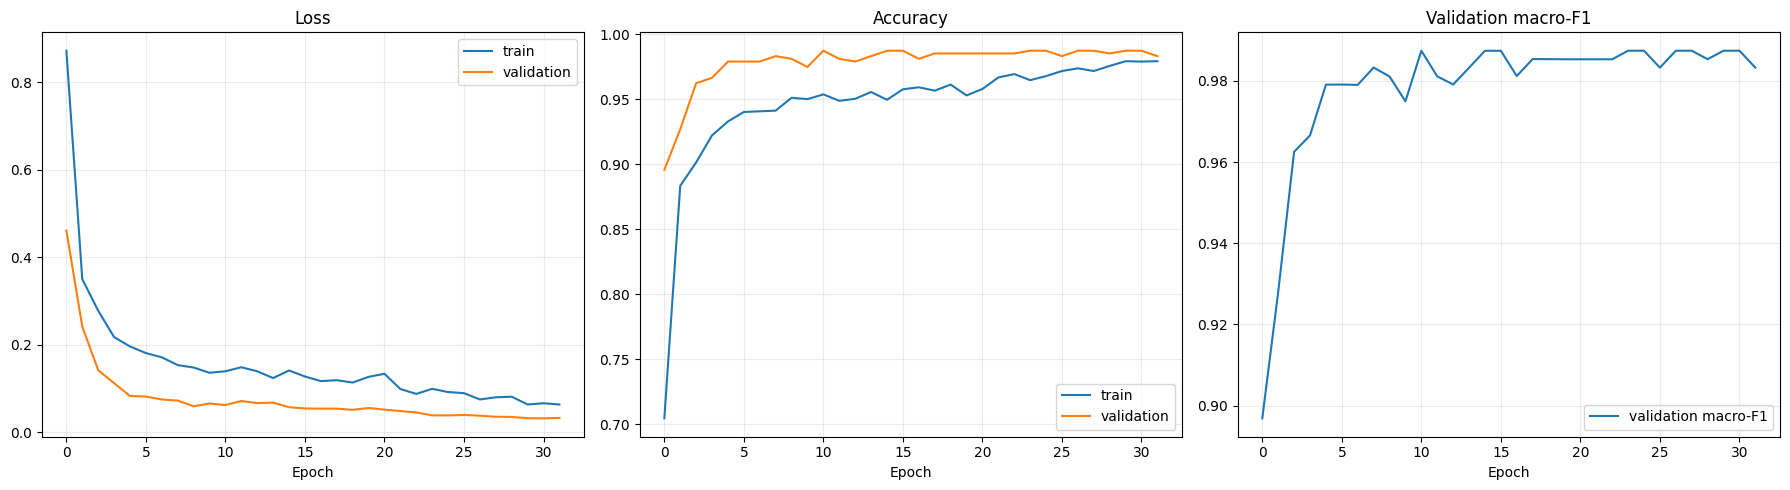

In [12]:
def merge_histories(*histories):
    merged = defaultdict(list)
    for history in histories:
        for key, values in history.history.items():
            merged[key].extend(values)
    return merged

all_history = merge_histories(history_head, history_finetune)
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

axes[0].plot(all_history["loss"], label="train")
axes[0].plot(all_history["val_loss"], label="validation")
axes[0].set_title("Loss")
axes[0].legend()

axes[1].plot(all_history["accuracy"], label="train")
axes[1].plot(all_history["val_accuracy"], label="validation")
axes[1].set_title("Accuracy")
axes[1].legend()

if "val_macro_f1" in all_history:
    axes[2].plot(all_history["val_macro_f1"], label="validation macro-F1")
axes[2].set_title("Validation macro-F1")
axes[2].legend()

for ax in axes:
    ax.set_xlabel("Epoch")
    ax.grid(alpha=0.25)
plt.tight_layout()
plt.show()


## 12. Select the best validation checkpoint and evaluate once on the test set

The test set is used only here. This section reports accuracy, balanced accuracy, macro-F1, weighted-F1, precision, recall, a complete classification report, and a normalized confusion matrix.


15/15 ━━━━━━━━━━━━━━━━━━━━ 8s 339ms/step
accuracy             0.9893
balanced_accuracy    0.9893
macro_precision      0.9896
macro_recall         0.9893
macro_f1             0.9893
weighted_f1          0.9894
dtype: float64


,precision,recall,f1-score,support
Aphids,1.0000,0.9744,0.9870,78.0000
Army worm,1.0000,0.9872,0.9935,78.0000
Bacterial blight,0.9753,1.0000,0.9875,79.0000
Healthy,1.0000,1.0000,1.0000,78.0000
Powdery mildew,1.0000,0.9872,0.9935,78.0000
Target spot,0.9620,0.9870,0.9744,77.0000
accuracy,0.9893,0.9893,0.9893,0.9893
macro avg,0.9896,0.9893,0.9893,468.0000
weighted avg,0.9896,0.9893,0.9894,468.0000


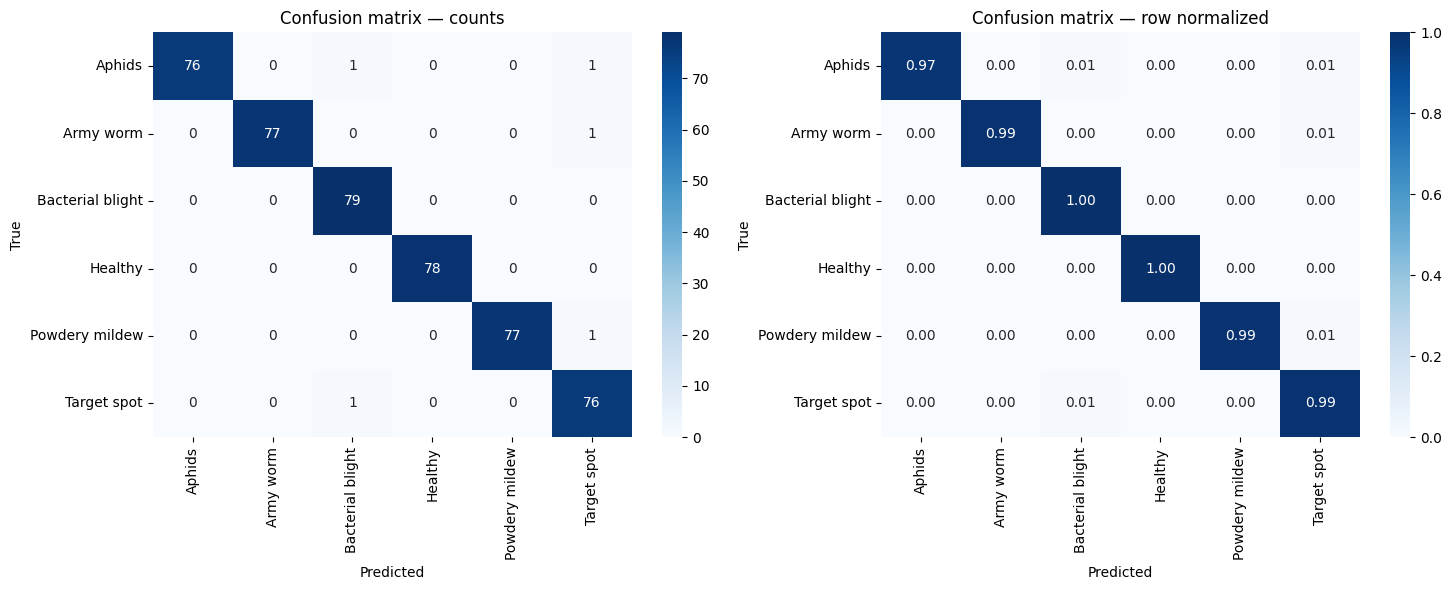

In [13]:
finetune_checkpoint = OUTPUT_DIR / "best_finetune.keras"
if finetune_checkpoint.exists():
    model = keras.models.load_model(finetune_checkpoint)

y_true = test_df["label"].to_numpy()
y_prob = model.predict(test_ds, verbose=1)
y_pred = np.argmax(y_prob, axis=1)

metrics = {
    "accuracy": accuracy_score(y_true, y_pred),
    "balanced_accuracy": balanced_accuracy_score(y_true, y_pred),
    "macro_precision": precision_score(y_true, y_pred, average="macro", zero_division=0),
    "macro_recall": recall_score(y_true, y_pred, average="macro", zero_division=0),
    "macro_f1": f1_score(y_true, y_pred, average="macro", zero_division=0),
    "weighted_f1": f1_score(y_true, y_pred, average="weighted", zero_division=0),
}
print(pd.Series(metrics).round(4))

report = classification_report(
    y_true, y_pred, target_names=CLASS_NAMES, digits=4, zero_division=0, output_dict=True
)
report_df = pd.DataFrame(report).transpose()
display(report_df.round(4))

cm = confusion_matrix(y_true, y_pred, labels=np.arange(NUM_CLASSES))
cm_norm = cm / cm.sum(axis=1, keepdims=True)
fig, axes = plt.subplots(1, 2, figsize=(15, 6))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=CLASS_NAMES, yticklabels=CLASS_NAMES, ax=axes[0])
axes[0].set_title("Confusion matrix — counts")
axes[0].set_xlabel("Predicted")
axes[0].set_ylabel("True")
sns.heatmap(cm_norm, annot=True, fmt=".2f", cmap="Blues", xticklabels=CLASS_NAMES, yticklabels=CLASS_NAMES, ax=axes[1])
axes[1].set_title("Confusion matrix — row normalized")
axes[1].set_xlabel("Predicted")
axes[1].set_ylabel("True")
plt.tight_layout()
plt.show()


## 13. Inspect high-confidence errors

High-confidence errors are useful for detecting ambiguous labels, background shortcuts, or visually similar diseases.


Test errors: 5


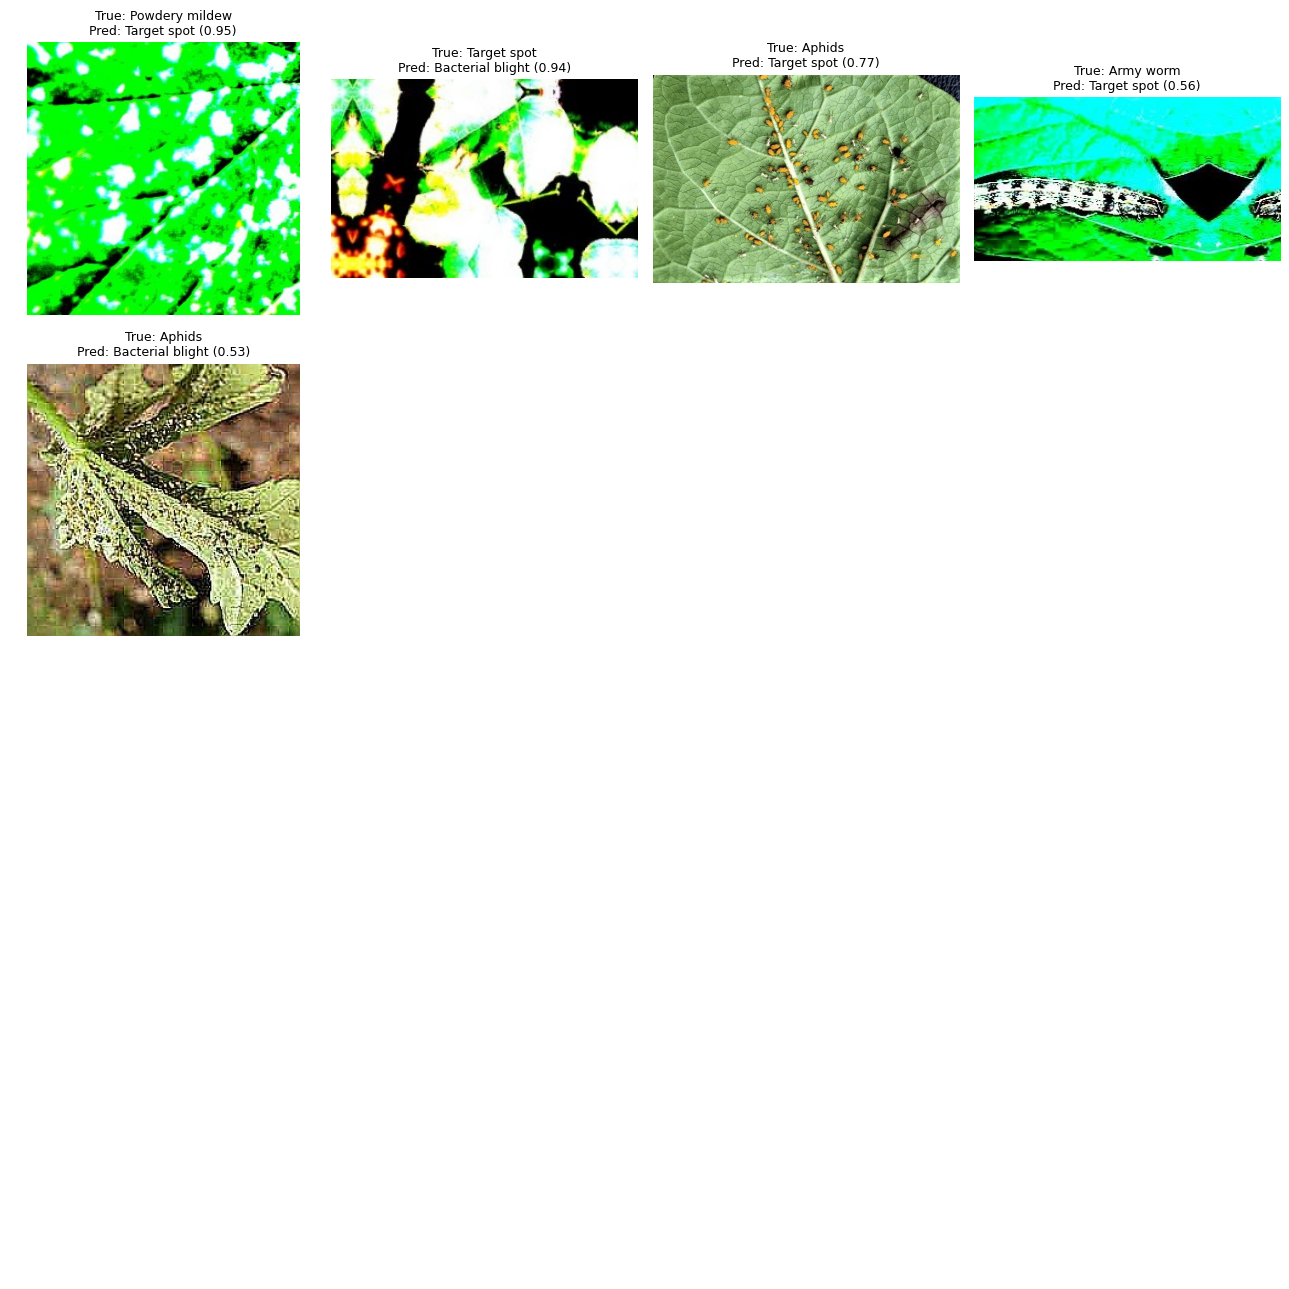

In [14]:
error_df = test_df.copy()
error_df["true_label"] = y_true
error_df["pred_label"] = y_pred
error_df["true_class"] = [CLASS_NAMES[i] for i in y_true]
error_df["pred_class"] = [CLASS_NAMES[i] for i in y_pred]
error_df["confidence"] = y_prob.max(axis=1)
errors = error_df[error_df.true_label != error_df.pred_label].sort_values("confidence", ascending=False)
print("Test errors:", len(errors))

if len(errors):
    sample_errors = errors.head(min(16, len(errors)))
    fig, axes = plt.subplots(4, 4, figsize=(13, 13))
    for ax in axes.flat:
        ax.axis("off")
    for ax, row in zip(axes.flat, sample_errors.itertuples()):
        with Image.open(row.filepath) as image:
            ax.imshow(image.convert("RGB"))
        ax.set_title(f"True: {row.true_class}\nPred: {row.pred_class} ({row.confidence:.2f})", fontsize=9)
        ax.axis("off")
    plt.tight_layout()
    plt.show()
else:
    print("No test errors to display.")


## 14. Save the model, label map, split manifests, and metrics

The saved artifacts make the experiment reproducible and allow the model to be used later without relying on notebook state.


In [15]:
model_path = OUTPUT_DIR / "cotton_efficientnetb0_final.keras"
model.save(model_path)

with open(OUTPUT_DIR / "class_names.json", "w") as handle:
    json.dump(CLASS_NAMES, handle, indent=2)

for name, frame in [("train", train_df), ("validation", val_df), ("test", test_df)]:
    frame.to_csv(OUTPUT_DIR / f"{name}_manifest.csv", index=False)

with open(OUTPUT_DIR / "test_metrics.json", "w") as handle:
    json.dump({k: float(v) for k, v in metrics.items()}, handle, indent=2)

print("Saved:", model_path)
print("Artifacts:", sorted(p.name for p in OUTPUT_DIR.iterdir()))


Saved: /kaggle/working/cotton_outputs/cotton_efficientnetb0_final.keras
Artifacts: ['best_finetune.keras', 'best_head.keras', 'class_names.json', 'cotton_efficientnetb0_final.keras', 'finetune_training.csv', 'head_training.csv', 'test_manifest.csv', 'test_metrics.json', 'train_manifest.csv', 'validation_manifest.csv']


## 15. Inference helper for a single image

This helper uses the same 256×256 RGB preprocessing as training and returns the ranked class probabilities.


In [16]:
def predict_one(image_path, trained_model=model):
    image = tf.io.read_file(str(image_path))
    image = tf.image.decode_image(image, channels=CHANNELS, expand_animations=False)
    image.set_shape([None, None, CHANNELS])
    image = tf.image.resize(image, IMAGE_SIZE, antialias=True)
    image = tf.cast(image, tf.float32) / 255.0
    probabilities = trained_model.predict(tf.expand_dims(image, axis=0), verbose=0)[0]
    result = pd.DataFrame({"class": CLASS_NAMES, "probability": probabilities})
    return result.sort_values("probability", ascending=False).reset_index(drop=True)

# Example:
# display(predict_one("/kaggle/input/cotton-plant-disease/Cotton leaves/40 Images/Healthy/1.jpg"))


In [18]:
display(predict_one("/kaggle/input/datasets/dhamur/cotton-plant-disease/Cotton leaves/40 Images/Aphids/1.jpg"))

2026-08-19 19:39:02.522111: E tensorflow/core/framework/node_def_util.cc:680] NodeDef mentions attribute use_unbounded_threadpool which is not in the op definition: Op<name=MapDataset; signature=input_dataset:variant, other_arguments: -> handle:variant; attr=f:func; attr=Targuments:list(type),min=0; attr=output_types:list(type),min=1; attr=output_shapes:list(shape),min=1; attr=use_inter_op_parallelism:bool,default=true; attr=preserve_cardinality:bool,default=false; attr=force_synchronous:bool,default=false; attr=metadata:string,default=""> This may be expected if your graph generating binary is newer  than this binary. Unknown attributes will be ignored. NodeDef: {{node ParallelMapDatasetV2/_14}}


,class,probability
0,Aphids,0.999571
1,Bacterial blight,0.000225
2,Target spot,0.000155
3,Powdery mildew,0.000040
4,Healthy,0.000006
5,Army worm,0.000003


## Experiment record

Record the following values alongside the final metrics: **4,788 total images; 3,840 train; 480 validation; 468 test; six classes; 256×256 RGB; batch size 32**. The principal evaluation metrics are test macro-F1, balanced accuracy, per-class recall, and the normalized confusion matrix—not accuracy alone.


## Executed experiment results

This section records the results from the executed EfficientNetB0 run stored in this notebook.

### Configuration and data

| Item | Executed value |
|---|---:|
| Dataset | Cotton leaves / 40 Images |
| Total images | 4,788 |
| Classes | 6 |
| Images per class | Aphids 800; Army worm 800; Bacterial blight 800; Healthy 800; Powdery mildew 800; Target spot 788 |
| Image size | 256 × 256 RGB |
| Batch size | 32 |
| Training / validation / test | 3,840 / 480 / 468 images |
| Batches | 120 / 15 / 15 |
| Random seed | 123 |
| Split method | File-level stratified split |
| Input pipeline range | `[0, 1]`; converted to `[0, 255]` before EfficientNet |
| Augmentation | Horizontal flip; rotation 0.08; zoom ±0.10; translation 0.08; contrast 0.15 |
| Backbone | EfficientNetB0 with ImageNet weights |
| Classifier | Global average pooling; batch normalization; dropout 0.35; six-unit softmax |
| Total parameters | 4,062,377 |
| Initial trainable parameters | 10,246 |
| Initial non-trainable parameters | 4,052,131 |

### Training stages and epochs

The frozen-backbone stage used Adam with learning rate **0.001**, sparse categorical cross-entropy, validation macro-F1 checkpointing, early stopping patience **8**, and ReduceLROnPlateau with factor **0.25**, patience **3**, and minimum learning rate **1e-7**. It ran for **19 epochs** before early stopping; the best checkpoint was from **epoch 11**, with validation accuracy **0.9875**, validation loss **0.0617**, and validation macro-F1 **0.9874**.

The fine-tuning stage unfroze the upper part of EfficientNet while keeping BatchNormalization layers frozen. The run reported **8 trainable layers** and used Adam with learning rate **1e-5**. It ran for **13 epochs** before early stopping; the best checkpoint was from **epoch 5**, with validation accuracy **0.9875**, validation loss **0.0381**, and validation macro-F1 **0.9874**. Across both stages, the notebook executed **32 epochs** in total.

### Test-set results

The final checkpoint evaluated all **468 test images** and produced **5 errors**.

| Metric | Score |
|---|---:|
| Accuracy | **0.9893** |
| Balanced accuracy | **0.9893** |
| Macro precision | **0.9896** |
| Macro recall | **0.9893** |
| Macro F1 | **0.9893** |
| Weighted precision | **0.9896** |
| Weighted recall | **0.9893** |
| Weighted F1 | **0.9894** |

### Per-class results

| Class | Precision | Recall | F1-score | Support |
|---|---:|---:|---:|---:|
| Aphids | 1.0000 | 0.9744 | 0.9870 | 78 |
| Army worm | 1.0000 | 0.9872 | 0.9935 | 78 |
| Bacterial blight | 0.9753 | 1.0000 | 0.9875 | 79 |
| Healthy | 1.0000 | 1.0000 | 1.0000 | 78 |
| Powdery mildew | 1.0000 | 0.9872 | 0.9935 | 78 |
| Target spot | 0.9620 | 0.9870 | 0.9744 | 77 |

The highest class-level F1-score was obtained for **Healthy (1.0000)**. The lowest was for **Target spot (0.9744)**. The very close accuracy, balanced accuracy, macro-F1, and weighted-F1 values indicate strong and relatively even performance across all six classes in this run.

### Saved artifacts

The run saved the final model as `cotton_efficientnetb0_final.keras`, together with `class_names.json`, train/validation/test manifests, `test_metrics.json`, the head and fine-tuning CSV logs, and the best head and fine-tuning checkpoints.
